In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# Run notebook from C&G_NodeChange (folder with runtime.csv, travelTime.csv, etc.)
base_path = Path(".").resolve()

# ── Shared style settings ──
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#cccccc",
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "font.family": "serif",
    "font.size": 12,
})

CPLEX_COLOR = "#E8860C"   # orange — optimum
GA_COLOR    = "#228B22"   # forest green
AC_COLOR    = "#4169E1"   # royal blue — ant colony
CW_COLOR    = "#8B008B"   # dark magenta — Clarke–Wright

# Column order in CSVs: CPLEX, GA, AC, CW
ALGO_KEYS = ("CPLEX", "GA", "AC", "CW")
ALGO_LABELS = {
    "CPLEX": "Optimum (CPLEX)",
    "GA": "Genetic algorithm",
    "AC": "Ant colony",
    "CW": "Clarke–Wright",
}
BAR_COLORS = (CPLEX_COLOR, GA_COLOR, AC_COLOR, CW_COLOR)
BAR_HATCHES = ("...", "///", "xx", "\\\\")


def plot_bar_from_csv(csv_name: str, y_label: str):
    """Grouped bar chart for CPLEX, GA, AC, and CW."""
    df = pd.read_csv(base_path / csv_name)
    nodes = df["node"].astype(str)
    n = len(nodes)
    x = np.arange(n)
    k = len(ALGO_KEYS)
    width = 0.18
    offsets = (np.arange(k) - (k - 1) / 2) * width

    fig, ax = plt.subplots(figsize=(11, 5))

    for idx, key in enumerate(ALGO_KEYS):
        if key not in df.columns:
            vals = np.full(n, np.nan)
        else:
            vals = pd.to_numeric(df[key], errors="coerce").values
        ax.bar(
            x + offsets[idx], vals, width,
            label=ALGO_LABELS[key], color=BAR_COLORS[idx],
            edgecolor="black", linewidth=0.8,
            hatch=BAR_HATCHES[idx],
        )

    stacked = np.concatenate(
        [pd.to_numeric(df[key], errors="coerce").values for key in ALGO_KEYS if key in df.columns]
    )
    stacked = stacked[~np.isnan(stacked)]
    if stacked.size == 0:
        ymin, ymax, y_range = 0.0, 1.0, 1.0
    else:
        ymin = float(np.nanmin(stacked))
        ymax = float(np.nanmax(stacked))
        y_range = ymax - ymin if ymax > ymin else 1.0
    label_offset = max(y_range * 0.02, 0.005)

    for idx, key in enumerate(ALGO_KEYS):
        if key not in df.columns:
            continue
        vals = pd.to_numeric(df[key], errors="coerce").values
        for j in range(n):
            h = vals[j]
            if np.isnan(h):
                continue
            cx = x[j] + offsets[idx] + width / 2
            ax.text(cx, h + label_offset, f"{h:g}", ha="center", va="bottom",
                    fontsize=8, fontweight="bold")

    ax.set_xlabel("Number of Nodes", fontsize=13, fontweight="bold")
    ax.set_ylabel(y_label, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(nodes, fontsize=12)
    ax.legend(title="Algorithm", fontsize=9, title_fontsize=10,
              frameon=True, fancybox=True, shadow=True, ncol=2)
    ax.set_axisbelow(True)

    margin = y_range * 0.15
    ax.set_ylim(bottom=max(0, ymin - margin * 2), top=ymax + margin)

    plt.tight_layout()
    plt.show()


def plot_runtime_line(csv_name: str = "runtime.csv"):
    """Line chart: all four methods. CSV runtimes are in seconds."""
    df = pd.read_csv(base_path / csv_name)
    nodes = pd.to_numeric(df["node"], errors="coerce").values

    fig, ax = plt.subplots(figsize=(10, 5))

    line_styles = [
        ("CPLEX", "#7B2D8E", "o", "--"),
        ("GA", GA_COLOR, "v", "-"),
        ("AC", AC_COLOR, "s", "-."),
        ("CW", CW_COLOR, "^", ":"),
    ]
    for key, color, marker, ls in line_styles:
        if key not in df.columns:
            continue
        y = pd.to_numeric(df[key], errors="coerce").values
        ax.plot(
            nodes, y,
            color=color, marker=marker, markersize=7,
            linestyle=ls, linewidth=2,
            label=ALGO_LABELS[key],
        )

    ax.set_xlabel("Number of Nodes", fontsize=13, fontweight="bold")
    ax.set_ylabel("Execution Time (sec)", fontsize=13, fontweight="bold")
    ax.set_xticks(nodes)
    ax.legend(title="Algorithm", fontsize=9, title_fontsize=10,
              frameon=True, fancybox=True, shadow=True, ncol=2)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()



## Runtime

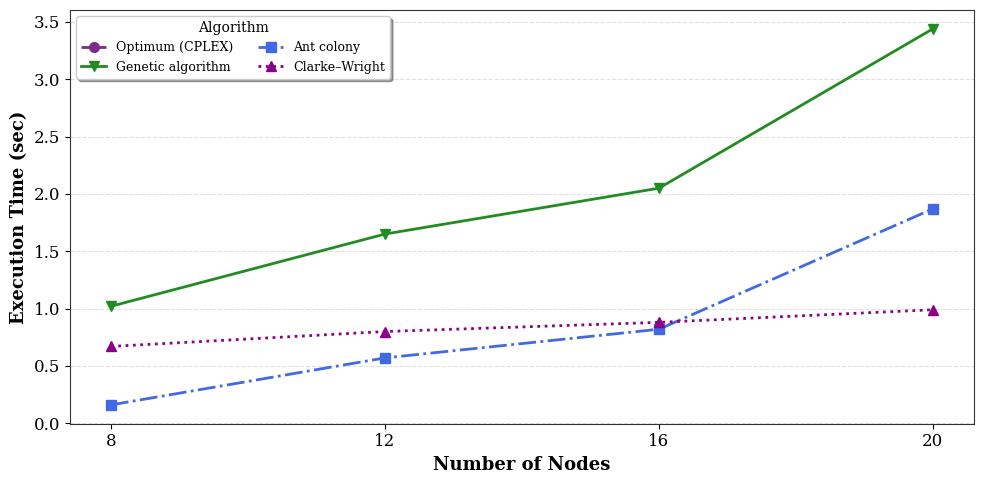

In [20]:
plot_runtime_line("runtime.csv")

## Distance

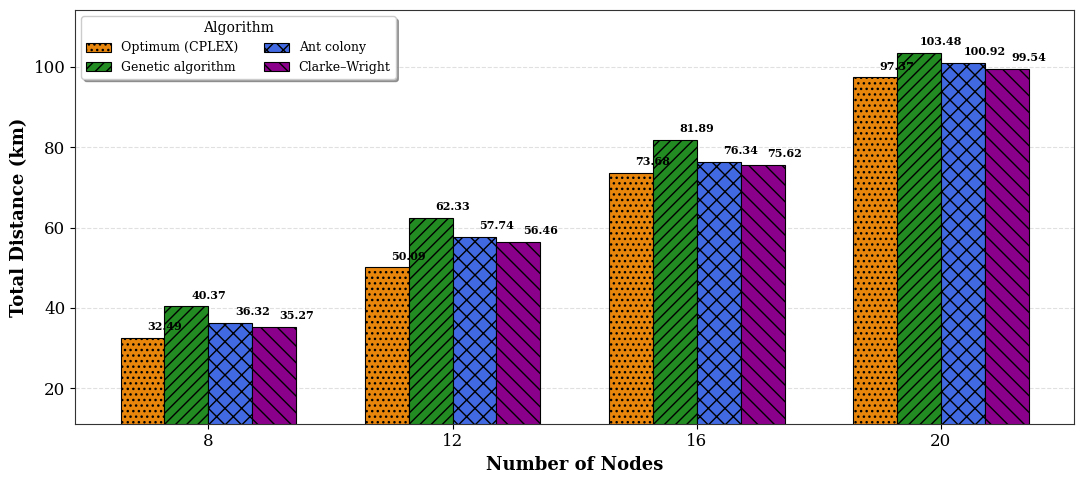

In [21]:
plot_bar_from_csv("distance.csv", "Total Distance (km)")

## Travel Time

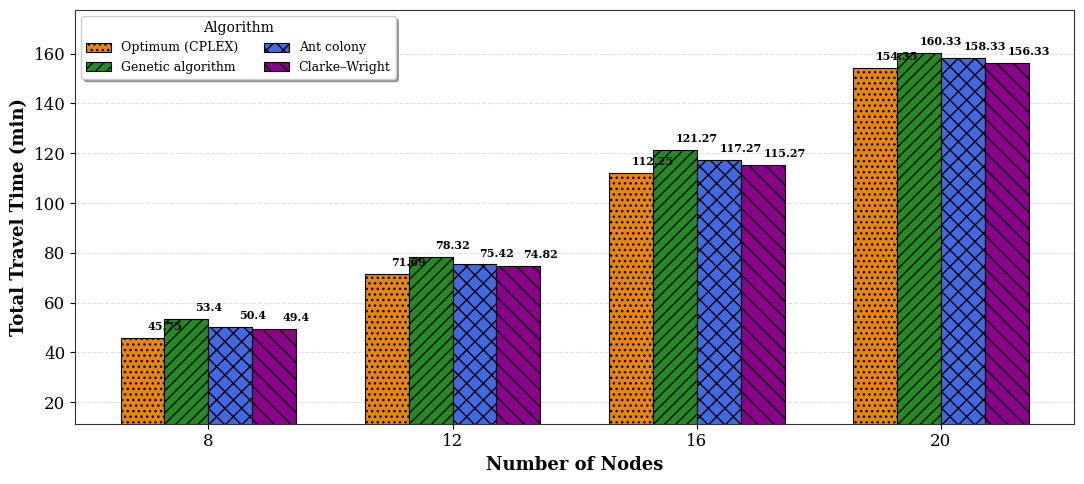

In [22]:
plot_bar_from_csv("travelTime.csv", "Total Travel Time (min)")

## Energy Consumption

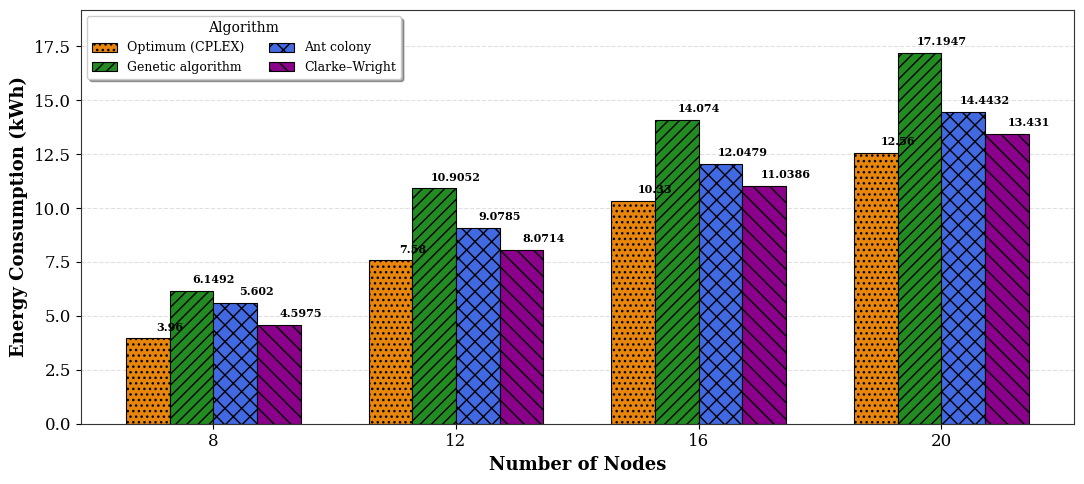

In [23]:
plot_bar_from_csv("energy_consumption.csv", "Energy Consumption (kWh)")

## Energy Charge (CS and ERS)

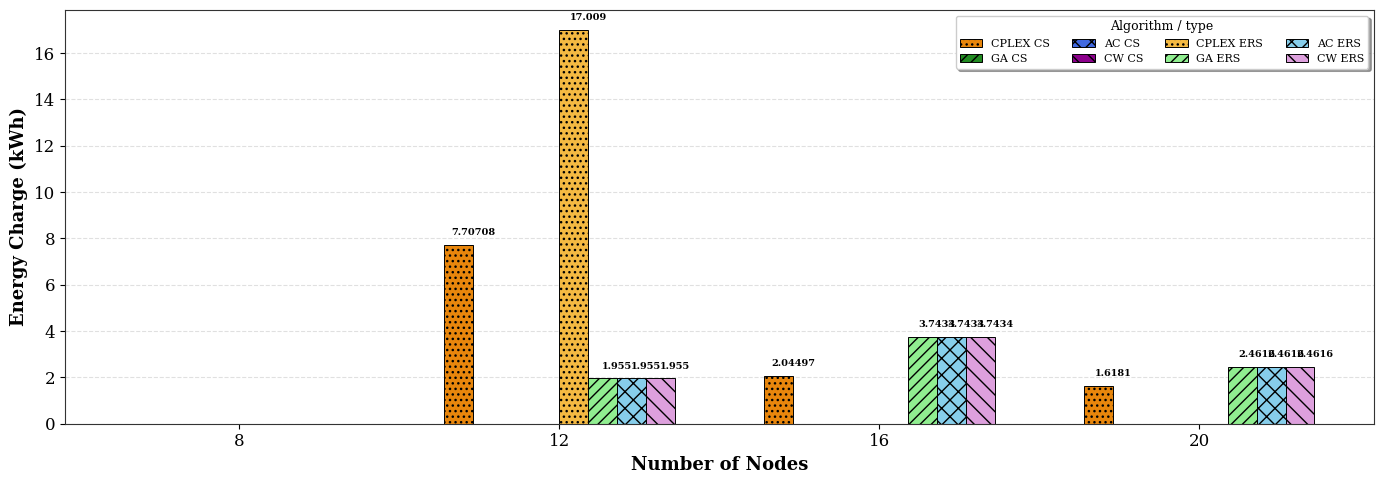

In [24]:
df_cs = pd.read_csv(base_path / "energy_charge_CS.csv")
df_ers = pd.read_csv(base_path / "energy_charge_ERS.csv")

nodes = df_cs["node"].astype(str).values
x = np.arange(len(nodes))

# Eight series: each algorithm × (CS | ERS)
plate = [
    ("CPLEX CS", df_cs["CPLEX"], CPLEX_COLOR, "..."),
    ("GA CS", df_cs["GA"], GA_COLOR, "///"),
    ("AC CS", df_cs["AC"], AC_COLOR, "xx"),
    ("CW CS", df_cs["CW"], CW_COLOR, "\\\\"),
    ("CPLEX ERS", df_ers["CPLEX"], "#F4B942", "..."),
    ("GA ERS", df_ers["GA"], "#90EE90", "///"),
    ("AC ERS", df_ers["AC"], "#87CEEB", "xx"),
    ("CW ERS", df_ers["CW"], "#DDA0DD", "\\\\"),
]

k = len(plate)
width = 0.09
offsets = (np.arange(k) - (k - 1) / 2) * width

fig, ax = plt.subplots(figsize=(14, 5))

all_flat = []
for idx, (label, series, color, hatch) in enumerate(plate):
    v = pd.to_numeric(series, errors="coerce").values
    all_flat.append(v)
    bars = ax.bar(
        x + offsets[idx], v, width,
        label=label, color=color,
        edgecolor="black", linewidth=0.7, hatch=hatch,
    )

stacked = np.concatenate(all_flat)
stacked = stacked[~np.isnan(stacked)]
y_range = float(np.nanmax(stacked) - np.nanmin(stacked)) if stacked.size else 1.0
if y_range <= 0:
    y_range = 1.0
label_offset = max(y_range * 0.02, 0.01)

for idx, (label, series, color, hatch) in enumerate(plate):
    v = pd.to_numeric(series, errors="coerce").values
    for j in range(len(x)):
        h = v[j]
        if np.isnan(h) or h <= 0:
            continue
        cx = x[j] + offsets[idx] + width / 2
        ax.text(cx, h + label_offset, f"{h:g}", ha="center", va="bottom",
                fontsize=7, fontweight="bold")

ax.set_xlabel("Number of Nodes", fontsize=13, fontweight="bold")
ax.set_ylabel("Energy Charge (kWh)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(nodes, fontsize=12)
ax.legend(title="Algorithm / type", fontsize=8, title_fontsize=9,
          frameon=True, fancybox=True, shadow=True, ncol=4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

